## MAPPING PREDICTION RESULTS

* Generating raster maps of neural network prediction results for future drinkning water nitrate

# Import Shapefiles

In [1]:
# States boundary file
import geopandas as gpd
states_path = 'D:/ArcGIS/Boundaries/States/conterminous_states_usgs/Conterminous_States_usgs.shp'
states = gpd.read_file(states_path)

In [2]:
# Read in point shapefiles (HUCs)
#import fiona
# import geopandas as gpd

# data_dir = "C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Data/Spatial/"

# # Define the path to your shapefile
# fp = data_dir + "huc12_points.shp"

# # Read the shapefile
# huc12_p = gpd.read_file(fp)


In [3]:
# Read in HUC12 shapefile (1m 4.2s)
# import fiona

# # 1. Define the path to your .gdb folder
# gdb_path = "D:/EnviroAtlas/NHDPlusV2_WBDSnapshot_EnviroAtlas_CONUS.gdb"

# # 2. List all feature classes (layers) inside the geodatabase
# layers = fiona.listlayers(gdb_path)
# print("Available layers:", layers)

# # 3. Read a specific feature class into a GeoDataFrame
# # (Replace 'your_layer_name' with one of the printed layers)
# huc12_s = gpd.read_file(gdb_path, layer="NHDPlusV2_WBDSnapshot_EnviroAtlas_CONUS")
# huc12_s.shape

In [4]:
# Read in NHD Catchments Shapefile (2m 11s)
import fiona
# 1. Define the path to your .gdb folder
gdb_path = 'D:/ArcGIS/NHDplusV2/Seamless/NHDPlusNationalData/NHDPlusV21_National_Seamless.gdb'

# 2. List all feature classes (layers) inside the geodatabase
layers = fiona.listlayers(gdb_path)
print("Available layers:", layers)

# 3. Read a specific feature class into a GeoDataFrame
# (Replace 'your_layer_name' with one of the printed layers)
cats_s = gpd.read_file(gdb_path, layer="Catchment")
cats_s.shape

Available layers: ['Gage', 'BurnAddLine', 'BurnAddWaterbody', 'LandSea', 'Sink', 'Wall', 'Catchment', 'CatchmentSP', 'NHDArea', 'NHDWaterbody', 'NHDPlusComponentVersions', 'PlusARPointEvent', 'PlusFlow', 'PlusFlowAR', 'NHDFCode', 'DivFracMP', 'BurnLineEvent', 'NHDFlowline_Network', 'NHDFlowline_NonNetwork', 'HUC12', 'GeoNetwork_Junctions', 'N_1_Desc', 'N_1_EDesc', 'N_1_EStatus', 'N_1_ETopo', 'N_1_FloDir', 'N_1_JDesc', 'N_1_JStatus', 'N_1_JTopo', 'N_1_JTopo2', 'N_1_Props']


c:\Users\MPennino\anaconda3\envs\map_env\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts.  The processing may be really slow.  You can skip the processing by setting METHOD=SKIP. Further messages of this type will be suppressed.
  return ogr_read(
c:\Users\MPennino\anaconda3\envs\map_env\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined. Further messages of this type will be suppressed.
  return ogr_read(


(2647454, 7)

In [5]:
cats_s = cats_s.rename(columns={'FEATUREID': 'COMID'})
type(cats_s), cats_s.columns


(geopandas.geodataframe.GeoDataFrame,
 Index(['GRIDCODE', 'COMID', 'SOURCEFC', 'AreaSqKM', 'Shape_Length',
        'Shape_Area', 'geometry'],
       dtype='str'))

In [ ]:
# Change projection (1 min 34s)
cats_meters = cats_s.to_crs("EPSG:5070")

# Remove cats_s from memory to free up space
del cats_s

# Import Prediction Dataset

In [691]:
# SW Datasets Select map file name to save at end of code
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_current_preds_COMID_raster_1000m_sw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_future4.5G_preds_COMID_raster_1000m_sw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_future8.5G_preds_COMID_raster_1000m_sw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_future4.5H_preds_COMID_raster_1000m_sw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_future8.5H_preds_COMID_raster_1000m_sw.tif'

#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_NUE15_preds_COMID_raster_1000m_sw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_Prod55_NUE0_preds_COMID_raster_1000m_sw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_Prod55_NUE15_preds_COMID_raster_1000m_sw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_RCP45G_Prod55_NUE0_preds_COMID_raster_1000m_sw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_RCP45G_Prod55_NUE15_preds_COMID_raster_1000m_sw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_RCP85H_Prod55_NUE15_preds_COMID_raster_1000m_sw.tif'

#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_current_preds_95CI_COMID_raster_1000m_sw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_current_preds_SE_COMID_raster_1000m_sw.tif'

#------------------------------------------------------------------------------------------------------------
# GW Datasets Select map file name to save at end of code
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_current_preds_COMID_raster_1000m_gw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_future4.5G_preds_COMID_raster_1000m_gw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_future8.5G_preds_COMID_raster_1000m_gw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_future4.5H_preds_COMID_raster_1000m_gw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_future8.5H_preds_COMID_raster_1000m_gw.tif'

#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_NUE15_preds_COMID_raster_1000m_gw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_Prod55_NUE0_preds_COMID_raster_1000m_gw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_Prod55_NUE15_preds_COMID_raster_1000m_gw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_RCP45G_Prod55_NUE0_preds_COMID_raster_1000m_gw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_RCP45G_Prod55_NUE15_preds_COMID_raster_1000m_gw.tif'
map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_RCP85H_Prod55_NUE15_preds_COMID_raster_1000m_gw.tif'

#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_current_preds_95CI_COMID_raster_1000m_gw.tif'
#map_path_name = 'D:/Data/OASES/Future_NO3/torch_image_current_preds_SE_COMID_raster_1000m_gw.tif'

In [692]:
# Load Prediction Results
import pandas as pd
import polars as pl
#import pyarrow as pa
#import pyarrow.parquet as pq

future_dir = 'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/OASES/Data/Future_NO3/'

# SW
#filename = 'torch_predictions_current_All_COMID_sw.parquet'  
#filename = 'torch_pred_scenario_fut_RCP4.5G_COMID_sw.parquet'
#filename = 'torch_pred_scenario_fut_RCP8.5G_COMID_sw.parquet'
#filename = 'torch_pred_scenario_fut_RCP4.5H_COMID_sw.parquet'
#filename = 'torch_pred_scenario_fut_RCP8.5H_COMID_sw.parquet'
#filename = 'torch_pred_scenario_nue15_COMID_sw.parquet'
#filename = 'torch_pred_scenario_prod55_nue0_COMID_sw.parquet'
#filename = 'torch_pred_scenario_prod55_nue15_COMID_sw.parquet'
#filename = 'torch_pred_scenario_fut_RCP45G_prod55_nue0_COMID_sw.parquet'
#filename = 'torch_pred_scenario_fut_RCP45G_prod55_nue15_COMID_sw.parquet'
#filename = 'torch_pred_scenario_fut_RCP85H_prod55_nue15_COMID_sw.parquet'
#filename = 'torch_predictions_current_95ci_COMID_sw.parquet'
#filename = 'torch_predictions_current_SE_COMID_sw.parquet'

# GW
#filename = 'torch_predictions_current_All_COMID_gw.parquet'
#filename = 'torch_pred_scenario_fut_RCP4.5G_COMID_gw.parquet'
#filename = 'torch_pred_scenario_fut_RCP8.5G_COMID_gw.parquet'
#filename = 'torch_pred_scenario_fut_RCP4.5H_COMID_gw.parquet'
#filename = 'torch_pred_scenario_fut_RCP8.5H_COMID_gw.parquet'
#filename = 'torch_pred_scenario_nue15_COMID_gw.parquet'
#filename = 'torch_pred_scenario_prod55_nue0_COMID_gw.parquet'
#filename = 'torch_pred_scenario_prod55_nue15_COMID_gw.parquet'
#filename = 'torch_pred_scenario_fut_RCP45G_prod55_nue0_COMID_gw.parquet'
#filename = 'torch_pred_scenario_fut_RCP45G_prod55_nue15_COMID_gw.parquet'
filename = 'torch_pred_scenario_fut_RCP85H_prod55_nue15_COMID_gw.parquet'
#filename = 'torch_predictions_current_SE_COMID_gw.parquet'

# Read the file
preds = pl.read_parquet(future_dir + filename)

# convert to pandas df
preds = preds.to_pandas()

preds.shape, type(preds)

((2644024, 2), pandas.DataFrame)

In [693]:
value1 = 100*len(preds[preds['Pred_Viol_Prob']>0.5])/len(preds)
print(f"{value1:.2f}% of the  predictions are above 0.5")



13.97% of the  predictions are above 0.5


In [694]:
pd.options.display.float_format = '{:.2f}'.format # gets it to display in two descipal places
 
print(preds['Pred_Viol_Prob'].describe())

# Summarize values > 0
#temp = preds[preds['Pred_Viol_Prob']>0.01]
#print(temp['Pred_Viol_Prob'].describe())


count   2483851.00
mean          0.20
std           0.26
min           0.00
25%           0.00
50%           0.06
75%           0.33
max           1.00
Name: Pred_Viol_Prob, dtype: float64


# Merge with Shapefile

In [695]:
# Merge Prediction results with Shapefile
#type(cats_s), cats_s.columns
preds_s = cats_meters.merge(preds, on="COMID", how="left")
preds_s.shape, preds_s.columns, type(preds_s)


((2647485, 8),
 Index(['GRIDCODE', 'COMID', 'SOURCEFC', 'AreaSqKM', 'Shape_Length',
        'Shape_Area', 'geometry', 'Pred_Viol_Prob'],
       dtype='str'),
 geopandas.geodataframe.GeoDataFrame)

In [696]:
print(preds_s.describe())

        GRIDCODE        COMID   AreaSqKM  Shape_Length  Shape_Area  \
count 2647485.00   2647485.00 2647485.00    2647485.00  2647485.00   
mean  1378860.90  22069897.06       3.12          0.09        0.00   
std    805405.46  92877291.87      70.81          0.10        0.01   
min         1.00   -504212.00       0.00          0.00        0.00   
25%    680949.00   6277671.00       0.41          0.04        0.00   
50%   1353175.00  12423105.00       1.43          0.08        0.00   
75%   2088143.00  19314124.00       3.17          0.12        0.00   
max   2825571.00 948100740.00   65014.44         28.65        7.00   

       Pred_Viol_Prob  
count      2483851.00  
mean             0.20  
std              0.26  
min              0.00  
25%              0.00  
50%              0.06  
75%              0.33  
max              1.00  


In [697]:
epsg_code = preds_s.crs.to_epsg()
print(epsg_code)

#EPSG 4269 is the unique ID for NAD83 (North American Datum 1983), a geographic coordinate system used for mapping locations in North America. 
# It measures positions using latitude and longitude in decimal degrees instead of flat meters

# EPSG 5070 is CONUS Albers units of meters

5070


In [698]:
# Check for how many catchments are missing
preds_s['Pred_Viol_Prob'].isna().sum() , 100*preds_s['Pred_Viol_Prob'].isna().sum()/len(preds_s)
# 1.6%

(np.int64(163634), np.float64(6.180733790748579))

In [699]:
import gc

# Triggers manual garbage collection sweep
gc.collect() 

4536

In [700]:
# Check projection
epsg_code = preds_s.crs.to_epsg()
epsg_code2 = states.crs.to_epsg()

print(epsg_code),print(epsg_code2)



5070
5070


(None, None)

In [701]:
len(preds_s)

2647485

# Generate Raster

In [702]:
# Run this iteratively as separate chunks (~6m20s for 1000m, 6m25s for 3000m, 6m 18s for 500m, 38m53s for 300m)
import geopandas as gpd
from geocube.api.core import make_geocube
import xarray as xr

# Fix the Xarray future warning globally
#xr.set_options(use_new_combine_kwarg_defaults=True)

chunk_size = 50000
total_rows = len(preds_s)
cubes = []

for start_idx in range(0, total_rows, chunk_size):
    end_idx = min(start_idx + chunk_size, total_rows)

    gdf_chunk = preds_s.iloc[start_idx:end_idx]

    cube_chunk = make_geocube(
        vector_data=gdf_chunk,
        measurements=["Pred_Viol_Prob"],  # Column containing pixel values   
        #measurements=["Pred_Viol_95ci_val"],  # Column containing pixel values (Use this for the 95% confidence interval values)  
        #measurements=["Pred_Viol_SE"],  # Column containing pixel values (Use this for the std error values)  

        resolution=(-1000, 1000)                  # Pixel size (Y, X) - Y is usually negative
        #like=master_grid,  # aligns subsequent chunks to the first grid
    )

    cubes.append(cube_chunk)


In [703]:
combined_cube = xr.merge(cubes)

C:\Users\MPennino\AppData\Local\Temp\ipykernel_22520\1695037155.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'y' ('y',) The recommendation is to set join explicitly for this case.
  combined_cube = xr.merge(cubes)
C:\Users\MPennino\AppData\Local\Temp\ipykernel_22520\1695037155.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'x' ('x',) The recommendation is to set join explicitly for this case.
  combined_cube = xr.merge(cubes)
C:\Users\MPennino\AppData\Local\Temp\ipykernel_22520\1695037155.py:1: Future

In [718]:
# 5. Save the final output to a raster file via rioxarray
#combined_cube["Pred_Viol_Prob"].rio.to_raster("torch_current_preds_COMID_raster_3000m_sw_v2.tif")
#combined_cube["Pred_Viol_Prob"].rio.to_raster("chunk1.tif")
combined_cube["Pred_Viol_Prob"].compute().rio.to_raster("chunk1.tif")
#combined_cube["Pred_Viol_95ci_val"].compute().rio.to_raster("chunk1.tif")
#combined_cube["Pred_Viol_SE"].compute().rio.to_raster("chunk1.tif")

#cubes[11]["Pred_Viol_Prob"].rio.to_raster("chunk1.tif") # testing that the individual list components each have the correct grid data

In [719]:
# Clip raster to CONUS boundary
import rioxarray

# 1. Load the shapefile and the raster
raster = rioxarray.open_rasterio("chunk1.tif", lock=False)

# 2. Ensure both layers share the same CRS
if states.crs != raster.rio.crs:
    states = states.to_crs(raster.rio.crs)

# 3. Clip the raster to the shapefile geometry
clipped_raster = raster.rio.clip(states.geometry, states.crs, drop=True)

# 4. Save the clipped raster to a new file
clipped_raster.rio.to_raster("chunk_clip.tif")
raster.close()
del raster

In [720]:
# Need to flip the raster when generate based on chunks
import numpy as np
import rasterio

with rasterio.open("chunk_clip.tif") as src:
    data = src.read()  # Reads all bands into a NumPy array
    meta = src.meta.copy()
    
    # Get original bounds
    left, bottom, right, top = src.bounds
flipped_data = np.flip(data, axis=1)

# 3. Calculate the new geospatial transform
# Since the image is upside down, the origin shifts from top-left to bottom-left 
# but we invert the pixel height resolution step to account for it.
new_transform = rasterio.transform.from_origin(left, bottom, src.res[0], src.res[1])

# 4. Update the metadata
meta.update({
    "transform": new_transform
})

# 5. Write the flipped raster to a new file
with rasterio.open("chunk_flipped.tif", "w", **meta) as dst:
    dst.write(flipped_data)


### Create a Map Image

In [707]:
# Create custom continuous colormap from a list of colors
import matplotlib.colors as mcolors
custom_b_y_r = mcolors.LinearSegmentedColormap.from_list("blue_yellow_red", ["blue","green" ,"yellow", "orange", "red"])

Finished at: 2026-09-16 13:00:46


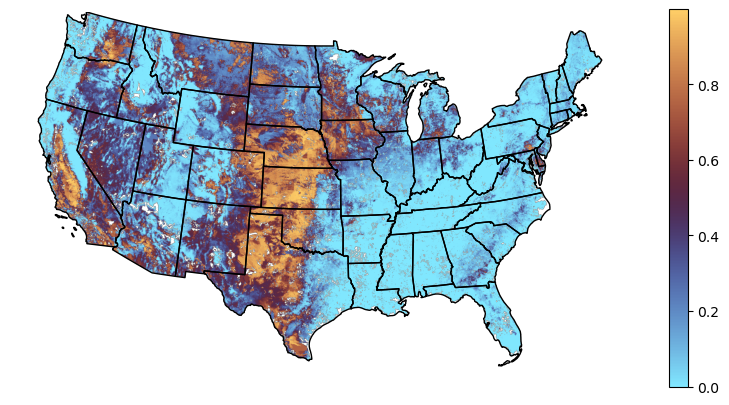

In [708]:
# (3 seconds to plot at 1000m, 31s at 300m)
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

#with rasterio.open(raster_path) as src:

# 1. Open the raster dataset
#raster_path =  "torch_current_preds_COMID_raster_1000m_sw.tif"
#raster_path =  "torch_current_preds_COMID_raster_3000m_sw_CONUS_v2.tif"
#raster_path =  "chunk_clip.tif"
raster_path = "chunk_flipped.tif"
src = rasterio.open(raster_path)

# 2. Load state boundaries vector file (e.g., Shapefile or GeoJSON)
# See above

# 3. Reproject vector boundaries to match the raster's CRS if needed
if states.crs != src.crs:
    states = states.to_crs(src.crs)

# 4. Create a matplotlib figure and axis
fig, ax = plt.subplots(figsize=(10, 7))

# 5. Plot the raster image on the axis
#show(src, ax=ax, title='Current SWDW Nitrate Violation Risk', cmap='terrain')


# 3. Use rasterio's built-in show function to render it onto the axis
# You can change the colormap (cmap) to options like 'terrain', or 'plasma', inferno, magma, YlOrRd
#  'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 
# 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 
# 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 
# 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 
# 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 
# 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 
# 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 
# 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 
# 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 
# 'gist_grey_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 
# 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gist_yerg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'grey_r', 
# 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'managua', 'managua_r', 'nipy_spectral', 'nipy_spectral_r', 
# 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'seismic', 'seismic_r', 
# 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 
# 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'vanimo', 'vanimo_r', 'viridis', 'viridis_r', 'winter', 'winter_r'

image_hidden = show(src, ax=ax, cmap='managua_r') # managua_r (for main maps), plasma (for 95CI maps), nipy_spectral_r, Spectral_r, RdYlBu_r, jet,,  turbo

# 4. Add map elements
#ax.set_title("My Raster Map", fontsize=16)
#ax.set_xlabel("Longitude / Easting")
#ax.set_ylabel("Latitude / Northing")

# Remove the outside axis, ticks, and frame completely
ax.set_axis_off()

# 5. Extract the image object to construct a matching color bar
fig.colorbar(image_hidden.get_images()[0], ax=ax, shrink=0.7)#,label="Risk")

# 6. Overlay the state boundaries
states.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.0)

# 6. Save the final map as a high-quality PNG or JPG image
#plt.savefig("raster_map.png", dpi=300, bbox_inches='tight')

# 7. Display the map on screen (optional)
#plt.imshow(src, origin="lower")
#plt.show()

# Print current time at the end
from datetime import datetime
print("Finished at:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


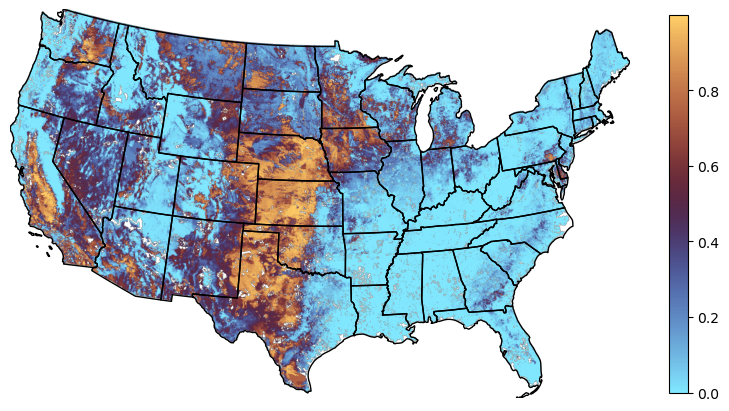

Finished at: 2026-09-16 13:16:32


In [ ]:
# This code generates plot with same dimensions as the "just_map" code
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

raster_path = "chunk_flipped.tif"

# Open your saved TIF file
with rasterio.open(raster_path) as src:
    #print("Band count:", src.count)
    #print("Data type:", src.dtypes)
    #print("Bounds:", src.bounds)

    fig, ax = plt.subplots(figsize=(10, 7))

   # Plot the first band with a grayscale or terrain colormap
    raster_img = show(src, 1, ax=ax, cmap='managua_r')  # managua_r (for main maps), plasma (for 95CI maps), nipy_spectral_r, Spectral_r, RdYlBu_r, jet,,  turbo

    # This prevents states.plot from resizing the view window away from your image
    raster_bounds = src.bounds
    ax.set_xlim(raster_bounds.left, raster_bounds.right)
    ax.set_ylim(raster_bounds.bottom, raster_bounds.top)
    
    # Extract the image object to construct a matching color bar
    #fig.colorbar(raster_img.get_images()[0], ax=ax, shrink=0.7)#,label="Risk")
    fig.colorbar(ax.images[0], ax=ax, shrink=0.7)

    # Overlay the state boundaries
    if states.crs != src.crs:
        states = states.to_crs(src.crs)
    states.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.0)

    ax.set_axis_off()
    plt.show()

# Print current time at the end
from datetime import datetime
print("Finished at:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

In [722]:
# Save Map Image (without CRS info) 
# type(src)
# import tifffile as tiff


# with rasterio.open('chunk_flipped.tif') as src:
#     # Read band 1 (or src.read() for all bands) into a numpy array
#     data = src.read(1)

# #tiff.imwrite('D:/Data/OASES/Future_NO3/torch_image_current_preds_COMID_raster_1000m_sw.tif', data)
# #tiff.imwrite('D:/Data/OASES/Future_NO3/torch_image_future4.5G_preds_COMID_raster_1000m_sw.tif', data)
# #tiff.imwrite('D:/Data/OASES/Future_NO3/torch_image_future8.5G_preds_COMID_raster_1000m_sw.tif', data)
# tiff.imwrite(map_path_name, data)


In [723]:
map_path_name

'D:/Data/OASES/Future_NO3/torch_image_RCP85H_Prod55_NUE15_preds_COMID_raster_1000m_gw.tif'

In [724]:
# Save Map Image with CRS

import os
import rasterio
from rasterio.transform import from_origin

#output_directory = "/path/to/your/folder"
#file_name = "chunk_flipped.tif"
#full_path = os.path.join(output_directory, file_name)

with rasterio.open('chunk_flipped.tif') as src:
    # Read band 1 (or src.read() for all bands) into a numpy array
    data = src.read(1)

# Using the location of the states shapefile to set the location of the raster
pixel_size = 1000 # Define your desired pixel resolution (in map units, e.g., meters or degrees)

xmin, ymin, xmax, ymax = states.total_bounds  
transform = from_origin(west=xmin, north=ymax, xsize=pixel_size, ysize=pixel_size)
#transform = from_origin(-125.0, 50.0, 0.01, 0.01)

with rasterio.open(
    map_path_name,
    "w",
    driver="GTiff",
    height=data.shape[0],
    width=data.shape[1],
    count=1,          # Number of bands
    dtype=data.dtype,
    crs="EPSG:5070",  # Your chosen CRS metadata
    transform=transform,
) as dst:
    dst.write(data, 1)  # Write data array to band 1

In [725]:
import os

# Delete from file explorer
with rasterio.open('chunk_clip.tif') as src:
    data = src.read()
# File automatically closes here
os.remove('chunk_clip.tif')  # Works perfectly

In [726]:
# Delete from file explorer
with rasterio.open('chunk_flipped.tif') as src:
    data = src.read()
# File automatically closes here
os.remove('chunk_flipped.tif')  # Works perfectly

In [727]:
# Delete from file explorer
with rasterio.open('chunk1.tif') as src:
    data = src.read()
src.close()
del src
# File automatically closes here
os.remove('chunk1.tif')  # Works perfectly

In [728]:
# Delete from file explorer
import glob
import os
#del_dir = "C:/Users/MPennino/GitHub_my_repos/Future_DW_NO3/Code/"

# Find all .tif files in the folder
files = glob.glob("C:/Users/MPennino/GitHub_my_repos/Future_DW_NO3/Code/*.tif")

# Delete each file
for file_path in files:
  os.remove(file_path)

In [729]:
# Print current time at the end
from datetime import datetime
print("Finished at:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Finished at: 2026-09-16 13:18:57
